In [2]:
import pandas as pd
import numpy as np

In [3]:
df = pd.read_csv(".\Salary_Data.csv")

In [4]:
df.head()

,YearsExperience,Salary
0,1.1,39343.0
1,1.3,46205.0
2,1.5,37731.0
3,2.0,43525.0
4,2.2,39891.0


In [5]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 2 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   YearsExperience  30 non-null     float64
 1   Salary           30 non-null     float64
dtypes: float64(2)
memory usage: 608.0 bytes


,YearsExperience,Salary
count,30.000000,30.000000
mean,5.313333,76003.000000
std,2.837888,27414.429785
min,1.100000,37731.000000
25%,3.200000,56720.750000
50%,4.700000,65237.000000
75%,7.700000,100544.750000
max,10.500000,122391.000000


In [6]:
X = df[["YearsExperience"]]
Y = df[["Salary"]]
X["intercept"] = 1

In [7]:
X_T = X.T

$$B = (X^T X)^{-1} X^T y$$

In [8]:
B = np.linalg.inv(X_T @ X) @ X_T @ Y
B.index = X.columns
A = X @ B
print(B)

                       Salary
YearsExperience   9449.962321
intercept        25792.200199


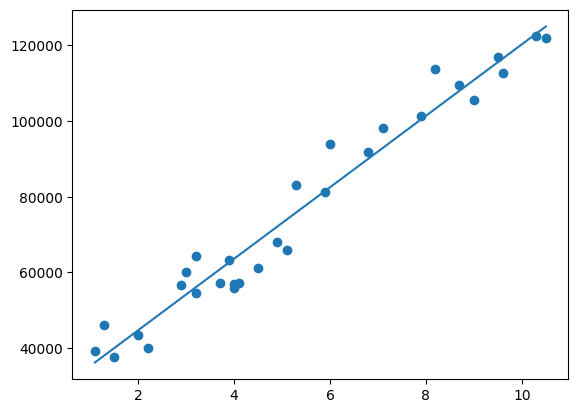

In [13]:
import matplotlib.pyplot as plt

plt.scatter(df["YearsExperience"], df["Salary"])
plt.plot(df["YearsExperience"], A["Salary"])
plt.show()

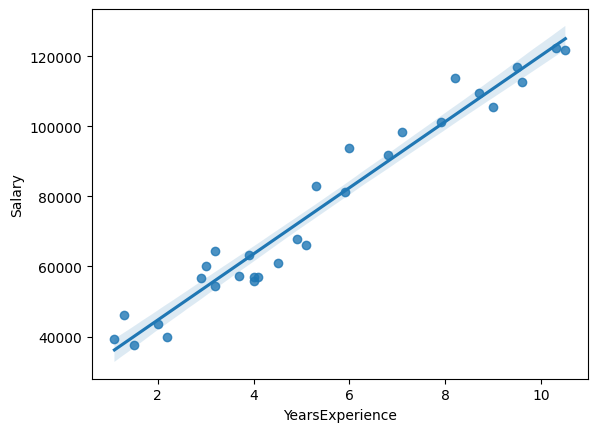

In [12]:
import seaborn as sns

sns.regplot(data=A, x=df["YearsExperience"], y=df["Salary"])
plt.show()

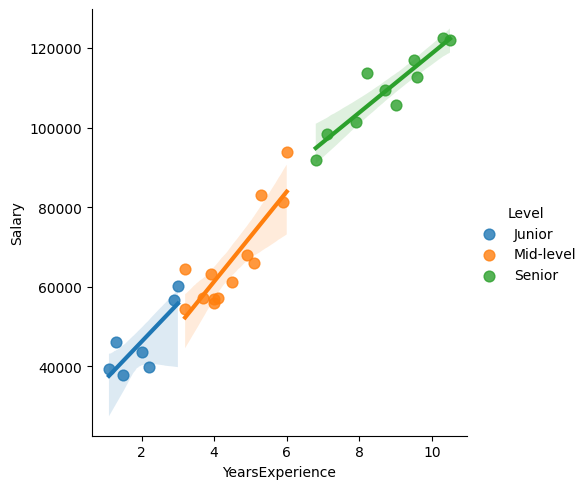

In [11]:
df["Level"] = pd.cut(
    df["YearsExperience"], bins=[0, 3, 6, 11], labels=["Junior", "Mid-level", "Senior"]
)
sns.lmplot(
    data=df,
    x="YearsExperience",
    y="Salary",
    hue="Level",
    truncate=True,
    scatter_kws={"s": 60},
    line_kws={"linewidth": 3},
)
plt.show()